# Fase 1 — Análisis del Dataset

**Objetivo:** Verificar la calidad del dataset, revisar imágenes, detectar errores, analizar distribuciones y documentar hallazgos antes de cualquier preprocesamiento.

**Metodología:** Cada experimento sigue 7 pasos: Teoría → Hipótesis → Implementación → Visualización → Análisis → Conclusiones → Decisión.

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working dir:", os.getcwd())

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# [NOTA] CONFIGURACIÓN — Ajusta estas rutas a tu estructura de carpetas
POS_DIR = 'dataset/positives'   # Carpeta con imágenes de furgonetas
NEG_DIR = 'dataset/negatives'   # Carpeta con imágenes de fondo/calles

# Recolectar todas las rutas de imágenes
valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

img_pos = sorted([
    os.path.join(POS_DIR, f) for f in os.listdir(POS_DIR)
    if f.lower().endswith(valid_ext)
]) if os.path.isdir(POS_DIR) else []

img_neg = sorted([
    os.path.join(NEG_DIR, f) for f in os.listdir(NEG_DIR)
    if f.lower().endswith(valid_ext)
]) if os.path.isdir(NEG_DIR) else []

print(f'Positivas encontradas: {len(img_pos)}')
print(f'Negativas encontradas: {len(img_neg)}')

Positivas encontradas: 3885
Negativas encontradas: 4479


Ejemplos de imágenes del Dataset (Arriba: Positivas | Abajo: Negativas)


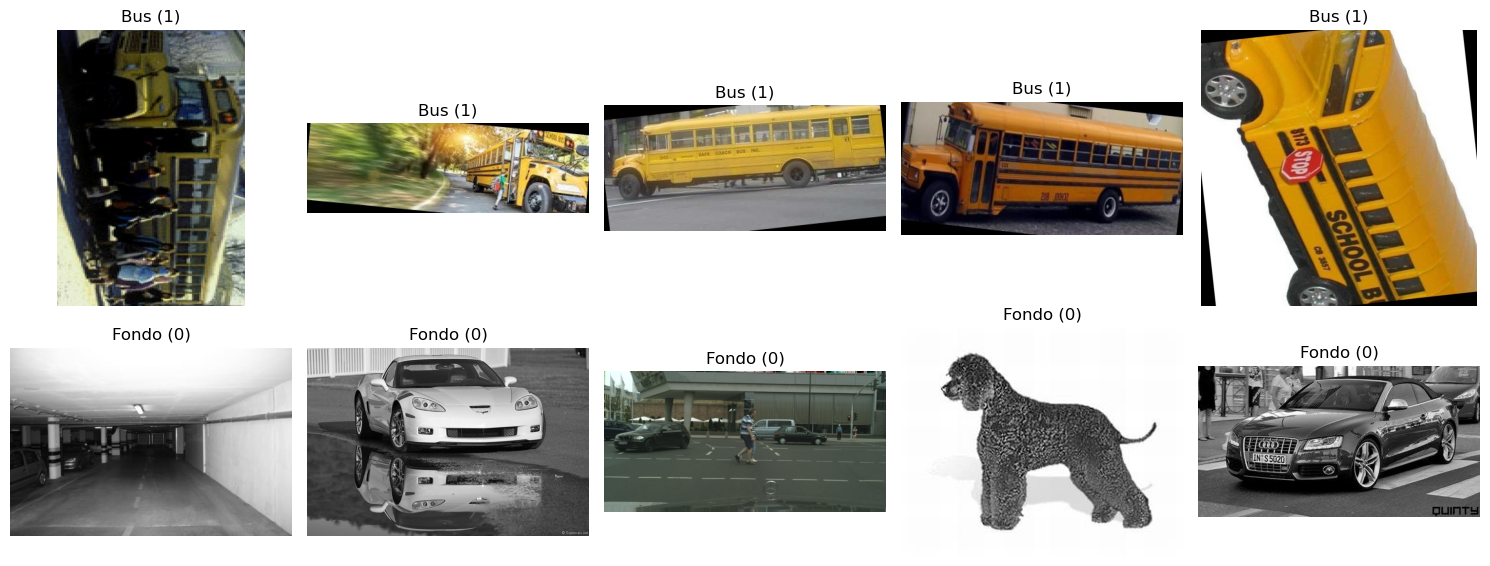

In [2]:
import random

# Mostrar ejemplos visuales del dataset
print("Ejemplos de imágenes del Dataset (Arriba: Positivas | Abajo: Negativas)")
fig, axs = plt.subplots(2, 5, figsize=(15, 6))

pos_samples = random.sample(img_pos, min(5, len(img_pos)))
neg_samples = random.sample(img_neg, min(5, len(img_neg)))

for i in range(5):
    # Positivas
    if i < len(pos_samples):
        img = cv2.imread(pos_samples[i])[..., ::-1] # BGR to RGB
        axs[0, i].imshow(img)
        axs[0, i].axis('off')
        axs[0, i].set_title("Bus (1)")
    # Negativas
    if i < len(neg_samples):
        img = cv2.imread(neg_samples[i])[..., ::-1]
        axs[1, i].imshow(img)
        axs[1, i].axis('off')
        axs[1, i].set_title("Fondo (0)")
plt.tight_layout()


# Fase 0: Ingesta Automática de Videos (Data Augmentation)
**Objetivo:** Si grabas un video en un entorno nuevo (ej. la universidad), pon su nombre en la lista `videos_to_process`. Esta celda extraerá 1 frame por segundo de ese video y los guardará en tu carpeta de imágenes negativas.

**Mecanismo de Seguridad:** Cuenta con un archivo `videos_procesados.json` que registra qué videos ya se han extraído. Si vuelves a correr la celda por error, el código no duplicará las imágenes.

In [3]:
import os
import cv2
import json

# 1. Define aquí los videos que quieras extraer (ej. 'universidad.mov')
videos_to_process = ["videos/cuarto.mov"] 
pos_dir = "dataset/positives"
neg_dir = "dataset/negatives"
log_file = "videos/videos_procesados.json"

if not os.path.exists(neg_dir):
    os.makedirs(neg_dir)

# Cargar registro de videos ya procesados para evitar duplicados
if os.path.exists(log_file):
    with open(log_file, "r") as f:
        procesados = json.load(f)
else:
    procesados = []

for vid_path in videos_to_process:
    if vid_path in procesados:
        print(f"[OK] El video '{vid_path}' ya fue procesado anteriormente. Saltando...")
        continue
        
    if not os.path.exists(vid_path):
        print(f"[ERROR] No se encontró el video '{vid_path}'. (Ignora esto si no lo has grabado aún)")
        continue
        
    print(f"[VIDEO] Procesando nuevo video: {vid_path}...")
    cap = cv2.VideoCapture(vid_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0: fps = 30 # fallback preventivo
    
    frame_count = 0
    saved_count = 0
    vid_name = os.path.splitext(os.path.basename(vid_path))[0]
    
    while True:
        ret, frame = cap.read()
        if not ret: break
            
        # Extraer 1 frame por segundo para no tener imágenes idénticas
        if frame_count % int(fps) == 0:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            out_path = os.path.join(neg_dir, f"{vid_name}_frame_{saved_count}.jpg")
            cv2.imwrite(out_path, gray)
            saved_count += 1
            
        frame_count += 1
        
    cap.release()
    print(f"[FOTO] Se extrajeron {saved_count} frames de '{vid_path}' y se guardaron en {neg_dir}.")
    procesados.append(vid_path)

# Actualizar el registro de seguridad
with open(log_file, "w") as f:
    json.dump(procesados, f)
print("\n[OK] Fase 0 completada.")


🎬 Procesando nuevo video: cuarto.mov...
📸 Se extrajeron 97 frames de 'cuarto.mov' y se guardaron en dataset/negatives.

✅ Fase 0 completada.


Muestra de los frames extraídos recientemente:


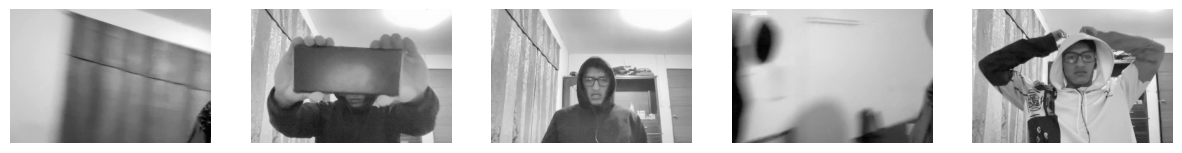

In [4]:
import matplotlib.pyplot as plt
import glob
import random
import cv2

print("Muestra de los frames extraídos recientemente:")
extracted_files = glob.glob(os.path.join(neg_dir, "*_frame_*.jpg"))
if len(extracted_files) > 0:
    samples = random.sample(extracted_files, min(5, len(extracted_files)))
    fig, axs = plt.subplots(1, len(samples), figsize=(15, 3))
    if len(samples) == 1: axs = [axs]
    for ax, img_path in zip(axs, samples):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    plt.show()
else:    print("No hay frames extraídos para mostrar.")


---

## Experimento 1.1: Balance de Clases

**1. Teoría:** Un SVM lineal asume que las clases tienen pesos similares. Si una clase domina (ej. 90% vs 10%), el hiperplano se desplaza hacia la clase minoritaria, generando un sesgo que favorece siempre a la clase mayoritaria.

**2. Hipótesis:** Si la diferencia entre positivas y negativas es menor al 20%, el dataset está suficientemente equilibrado para entrenar un SVM sin necesidad de técnicas de compensación.

Total Positivas (Furgonetas): 3885
Total Negativas (Calles/Fondos): 4479
Ratio Pos/Neg: 0.87


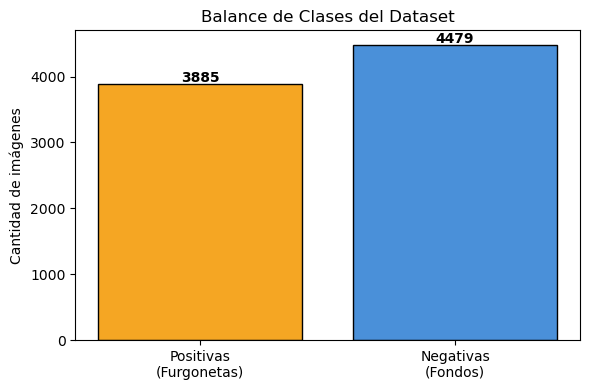

In [5]:
# 3. Implementación + 4. Visualización
n_pos = len(img_pos)
n_neg = len(img_neg)
total = n_pos + n_neg

print(f'Total Positivas (Furgonetas): {n_pos}')
print(f'Total Negativas (Calles/Fondos): {n_neg}')
print(f'Ratio Pos/Neg: {n_pos/max(n_neg,1):.2f}')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Positivas\n(Furgonetas)', 'Negativas\n(Fondos)'],
              [n_pos, n_neg], color=['#F5A623', '#4A90D9'], edgecolor='black')
ax.set_ylabel('Cantidad de imágenes')
ax.set_title('Balance de Clases del Dataset')
for bar, count in zip(bars, [n_pos, n_neg]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---

## Experimento 1.2: Distribución de Resoluciones y Aspect Ratio

**1. Teoría:** HOG requiere que todas las imágenes tengan exactamente el mismo tamaño al entrar al SVM. El Aspect Ratio promedio de las imágenes positivas determinará el tamaño ideal de la ventana de detección para no distorsionar los gradientes.

**2. Hipótesis:** Si las furgonetas son más anchas que altas, usar una ventana cuadrada (64×64) distorsionará la geometría real del vehículo y degradará el rendimiento del clasificador.

Analizando dimensiones de las imágenes positivas...


100%|██████████| 3885/3885 [00:08<00:00, 439.59it/s]


Aspect Ratio Promedio (Ancho/Alto): 1.30
Ancho Promedio: 559 px
Alto Promedio: 455 px


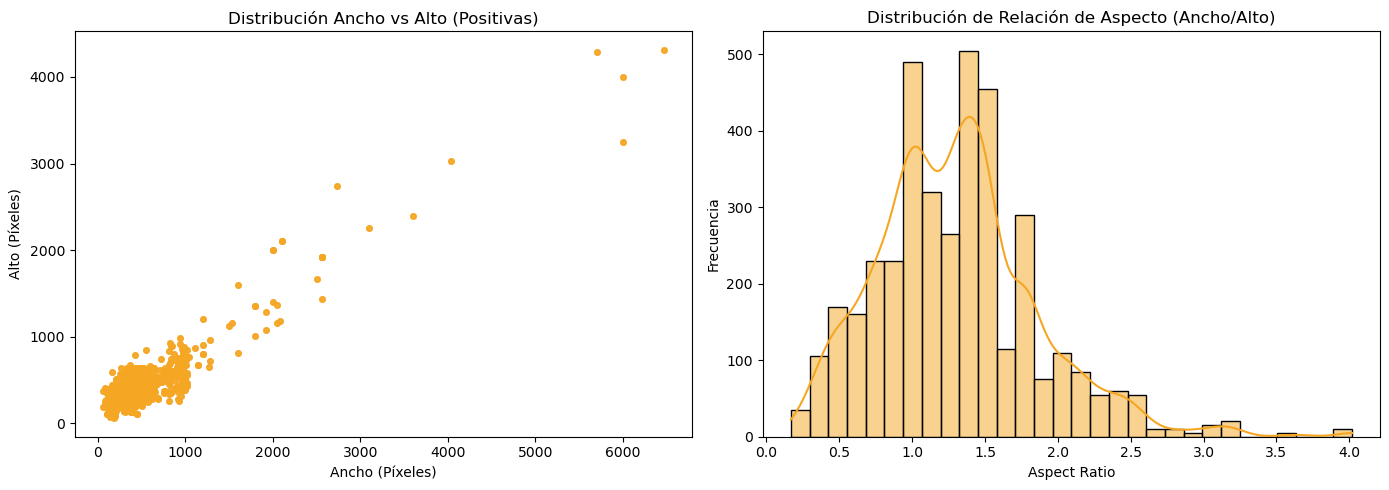

In [6]:
# 3. Implementación + 4. Visualización
anchos_pos = []
altos_pos = []
aspect_ratios_pos = []

print("Analizando dimensiones de las imágenes positivas...")
for ruta in tqdm(img_pos):
    img = cv2.imread(ruta)
    if img is not None:
        h, w = img.shape[:2]
        anchos_pos.append(w)
        altos_pos.append(h)
        aspect_ratios_pos.append(w / h)

print(f'\nAspect Ratio Promedio (Ancho/Alto): {np.mean(aspect_ratios_pos):.2f}')
print(f'Ancho Promedio: {np.mean(anchos_pos):.0f} px')
print(f'Alto Promedio: {np.mean(altos_pos):.0f} px')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(anchos_pos, altos_pos, alpha=0.4, s=15, color='#F5A623')
axes[0].set_xlabel('Ancho (Píxeles)')
axes[0].set_ylabel('Alto (Píxeles)')
axes[0].set_title('Distribución Ancho vs Alto (Positivas)')

sns.histplot(aspect_ratios_pos, bins=30, kde=True, color='#F5A623', ax=axes[1])
axes[1].set_xlabel('Aspect Ratio')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Relación de Aspecto (Ancho/Alto)')

plt.tight_layout()
plt.show()

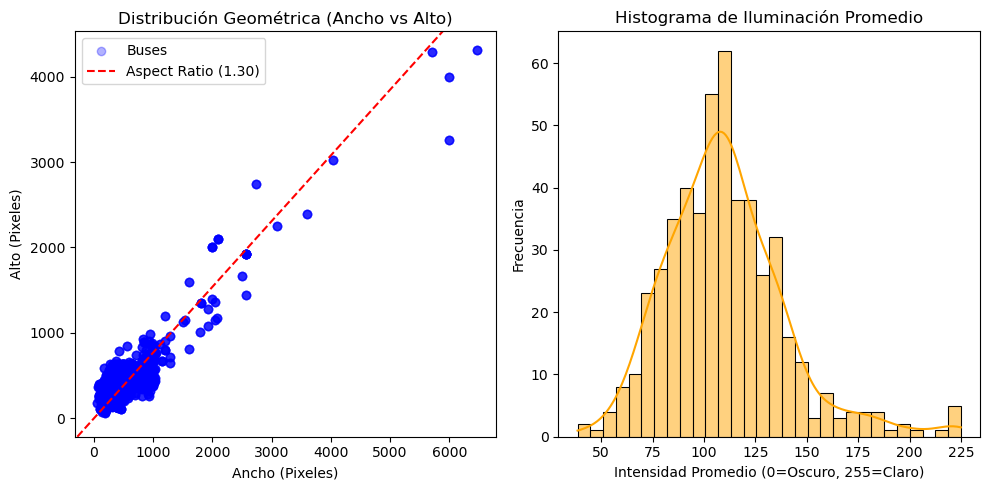

In [7]:
# Scatter plot de resoluciones
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(anchos_pos, altos_pos, alpha=0.3, color='blue', label='Buses')
plt.title('Distribución Geométrica (Ancho vs Alto)')
plt.xlabel('Ancho (Pixeles)')
plt.ylabel('Alto (Pixeles)')
plt.axline((0, 0), slope=1/1.3, color='red', linestyle='--', label='Aspect Ratio (1.30)')
plt.legend()

# Histograma de Iluminación (Brillo)
plt.subplot(1, 2, 2)
# Calculamos brillo promedio para una muestra de imágenes
brillos_sample = []
for p in random.sample(img_pos, min(500, len(img_pos))):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None: brillos_sample.append(np.mean(img))
    
sns.histplot(brillos_sample, bins=30, kde=True, color='orange')
plt.title('Histograma de Iluminación Promedio')
plt.xlabel('Intensidad Promedio (0=Oscuro, 255=Claro)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


---

## Experimento 1.3: Detección de Imágenes Corruptas o Atípicas (Outliers)

**1. Teoría:** Entrenar con imágenes totalmente negras, blancas, o extremadamente borrosas introduce ruido puro en el SVM, empeorando el margen de separación.

**2. Hipótesis:** Utilizando el operador Laplaciano (que mide la cantidad de bordes/nitidez) y la media de intensidad de píxeles (brillo), podemos identificar estadísticamente cuáles imágenes son 'sospechosas' y deberían revisarse manualmente para ser eliminadas.

**3. Implementación:** Calcularemos la varianza del Laplaciano y el brillo promedio para todas las imágenes positivas, y mostraremos aquellas que estén en los niveles más bajos.

In [8]:
print("Evaluando calidad y nitidez de imágenes positivas...")
brillos = []
nitidez = []
rutas_sospechosas = []

for ruta in tqdm(img_pos):
    img = cv2.imread(ruta)
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brillo = np.mean(gray)
        laplaciano = cv2.Laplacian(gray, cv2.CV_64F).var()  # Varianza = nitidez

        brillos.append(brillo)
        nitidez.append(laplaciano)

        # Regla simple para encontrar outliers: muy oscuras o muy borrosas
        if brillo < 20 or laplaciano < 100:
            rutas_sospechosas.append((ruta, brillo, laplaciano))

print(f"\nSe encontraron {len(rutas_sospechosas)} imágenes potencialmente corruptas/borrosas.")
if rutas_sospechosas:
    print("Ejemplos a revisar:")
    for r, b, l in rutas_sospechosas[:5]:
        print(f"- {os.path.basename(r)} (Brillo: {b:.1f}, Nitidez: {l:.1f})")

Evaluando calidad y nitidez de imágenes positivas...


100%|██████████| 3885/3885 [00:17<00:00, 224.66it/s]


Se encontraron 104 imágenes potencialmente corruptas/borrosas.
Ejemplos a revisar:
- 15208199_082024-wtvd-new-school-bus-img_jpg.rf.69828b8b62ea574a23fff07caafaf9ed.jpg (Brillo: 129.9, Nitidez: 31.0)
- 5065_c001minischoolbus_jpg.rf.a65f59cec20a95f074bb711b2291191c.jpg (Brillo: 207.7, Nitidez: 53.0)
- 5e67dfb8-d40b-48fb-8e54-84543bae85f8_jpeg.rf.940d95b69ae1280ff7c72aaed1591664.jpg (Brillo: 118.7, Nitidez: 77.9)
- 819UhDjOe5L_jpg.rf.f5867f7684d21609a0a5b45b7993157f.jpg (Brillo: 166.2, Nitidez: 79.6)
- Blue-Bird-Vision-Electric-PNG-10-8-18-1_png.rf.de1f0213f8e16564e2df4aec939e358e.jpg (Brillo: 222.6, Nitidez: 76.8)


---

# Fase 2 — Preprocesamiento

**Objetivo:** Determinar el mejor tratamiento previo de las imágenes antes de pasarlas al extractor HOG.

---

## Experimento 2.1: Espacios de Color (Grayscale vs RGB) y el Impacto del Color

**1. Teoría:** HOG calcula la magnitud y dirección del cambio rápido de intensidad de píxeles (bordes). Este cambio de intensidad geométrica está casi totalmente contenido en el canal de luminancia (luz/sombra), no en la crominancia (el color). De hecho, Dalal & Triggs (los creadores de HOG) demostraron que usar RGB frente a Escala de Grises aporta una mejora minúscula (<1%) a costa de multiplicar por 3 el costo computacional en tiempo real.

**2. Hipótesis:** HOG es **ciego al color**. El algoritmo aprenderá la 'silueta' o 'estructura' de la furgoneta escolar (su forma rectangular, bordes, llantas, ventanas). Por lo tanto, **podemos usar furgonetas de CUALQUIER color** en nuestro dataset de entrenamiento, siempre y cuando mantengan la misma estructura geométrica (sean furgonetas tipo van).

**3. Implementación:** Tomaremos una furgoneta del dataset, la convertiremos a escala de grises y calcularemos sus bordes usando el filtro de *Sobel* (el corazón de HOG), para visualizar cómo la información del color desaparece por completo, pero la silueta estructural del carro es lo único que HOG necesita.

Visualizando estructura geométrica sin color...


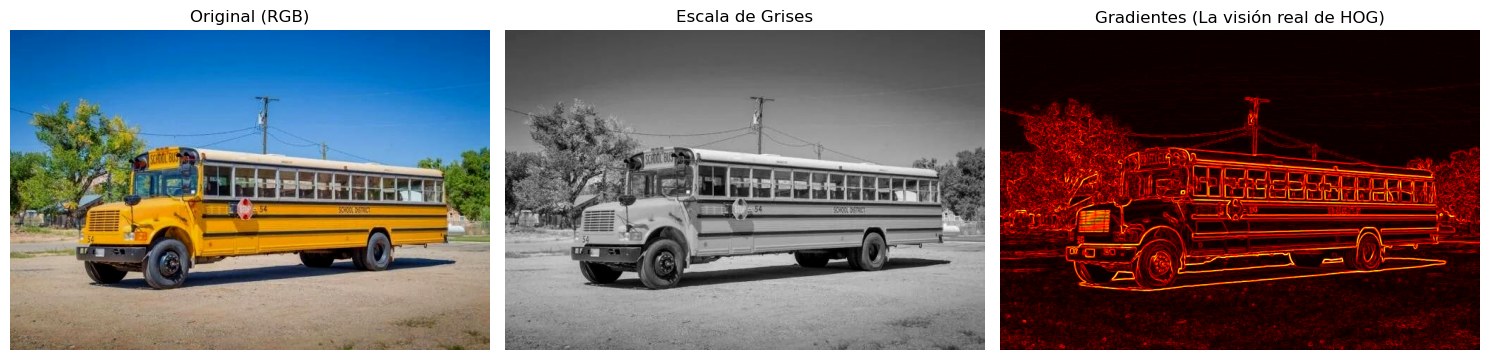

In [9]:
import random

print("Visualizando estructura geométrica sin color...")
# Tomamos una imagen aleatoria (ejecuta varias veces para ver distintas fotos)
img_path = img_pos[random.randint(0, len(img_pos)-1)]
img_color = cv2.imread(img_path)
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# 1. Convertimos a Escala de Grises
img_gray = cv2.cvtColor(img_color, cv2.COLOR_RGB2GRAY)

# 2. Extraemos los gradientes (Bordes en X e Y) que es lo único que ve HOG
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
magnitud = cv2.magnitude(sobelx, sobely)

# 3. Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_color)
axes[0].set_title('Original (RGB)')
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Escala de Grises')
axes[1].axis('off')

axes[2].imshow(magnitud, cmap='hot')
axes[2].set_title('Gradientes (La visión real de HOG)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

---

## Experimento 2.2: Mejora de Contraste (CLAHE)

**1. Teoría:** Dado que HOG depende de los gradientes (diferencia matemática de luz entre píxeles adyacentes), las imágenes muy opacas, oscuras o de días nublados generarán gradientes débiles. CLAHE (*Contrast Limited Adaptive Histogram Equalization*) mejora el contraste localmente sin sobreexponer la imagen, marcando mejor las diferencias de luz.

**2. Hipótesis:** Aplicar CLAHE a la escala de grises resaltará los bordes estructurales de la furgoneta (como las ventanas y las llantas contra el asfalto), haciendo que los vectores de HOG sean más fuertes y consistentes, lo que facilitará la tarea de separación del SVM.

**3. Implementación:** Aplicaremos CLAHE a una imagen y compararemos los gradientes resultantes antes y después del filtro.

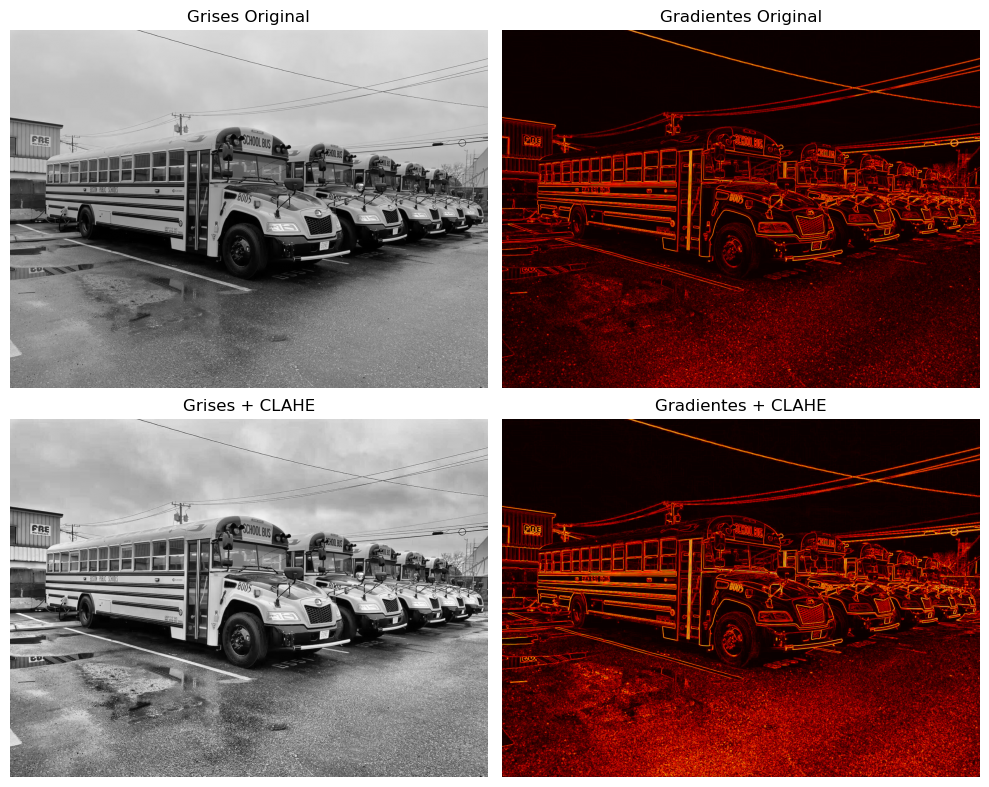

In [10]:
# Tomamos una imagen (puedes cambiar el índice para probar distintas fotos)
img_path = img_pos[0]
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Aplicar CLAHE (Ecualización Adaptativa de Histograma)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img)

# Gradientes sin CLAHE
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
mag_normal = cv2.magnitude(sobelx, sobely)

# Gradientes con CLAHE
sobelx_c = cv2.Sobel(img_clahe, cv2.CV_64F, 1, 0, ksize=3)
sobely_c = cv2.Sobel(img_clahe, cv2.CV_64F, 0, 1, ksize=3)
mag_clahe = cv2.magnitude(sobelx_c, sobely_c)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0,0].imshow(img, cmap='gray')
axes[0,0].set_title('Grises Original')
axes[0,1].imshow(mag_normal, cmap='hot')
axes[0,1].set_title('Gradientes Original')

axes[1,0].imshow(img_clahe, cmap='gray')
axes[1,0].set_title('Grises + CLAHE')
axes[1,1].imshow(mag_clahe, cmap='hot')
axes[1,1].set_title('Gradientes + CLAHE')

for ax in axes.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()

---

## Experimento 2.3: Redimensionamiento Geométrico (Padding vs Resize Directo)

**1. Teoría:** Como descubrimos en el Experimento 1.2, nuestro *Aspect Ratio* promedio es **1.29** (furgonetas anchas). El algoritmo clásico de HOG exige que todas las imágenes entren al SVM con exactamente el mismo tamaño. Si tomamos una foto ancha de 900×700 y le hacemos un `cv2.resize()` directo a 64×64, el carro se comprimirá horizontalmente, distorsionando los ángulos reales de sus gradientes.

**2. Hipótesis:** Aplicar bandas negras (Padding/Relleno) para convertir la imagen rectangular en un cuadrado perfecto de 64×64 preservará los ángulos reales de los gradientes, resultando en un modelo matemáticamente más fiel a la realidad que un `resize` aplastado.

**3. Implementación:** Compararemos visualmente un Resize forzado (aplastado) contra un Resize inteligente con Padding, observando la distorsión del vehículo.

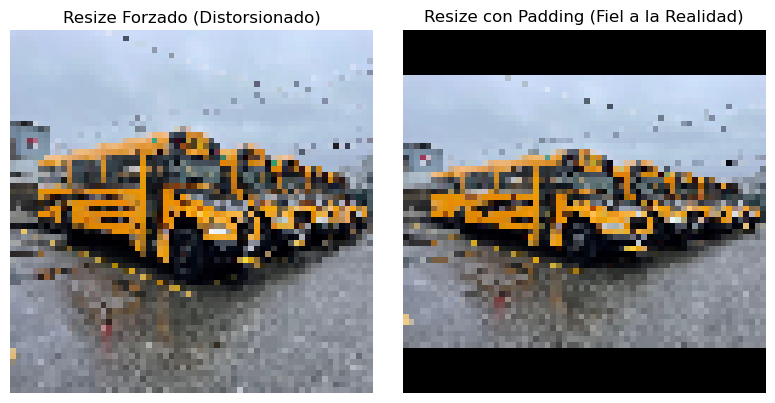

In [11]:
def resize_con_padding(img, size=(64, 64)):
    h, w = img.shape[:2]
    scale = min(size[0]/w, size[1]/h)
    nw, nh = int(w*scale), int(h*scale)
    img_resized = cv2.resize(img, (nw, nh))

    top = (size[1] - nh) // 2
    bottom = size[1] - nh - top
    left = (size[0] - nw) // 2
    right = size[0] - nw - left

    # Añadimos bordes negros para rellenar (Padding)
    return cv2.copyMakeBorder(img_resized, top, bottom, left, right,
                              cv2.BORDER_CONSTANT, value=[0,0,0])

img_path = img_pos[0]
img_color = cv2.imread(img_path)
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# 1. Resize Forzado a 64x64 (Aspect Ratio 1:1, ignorando proporciones reales)
img_aplastada = cv2.resize(img_color, (64, 64))

# 2. Resize Inteligente con Padding a 64x64
img_padding = resize_con_padding(img_color, (64, 64))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_aplastada)
axes[0].set_title('Resize Forzado (Distorsionado)')
axes[0].axis('off')

axes[1].imshow(img_padding)
axes[1].set_title('Resize con Padding (Fiel a la Realidad)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Experimento 2.4: Definición de la Ventana HOG (Window Size)

- **El Problema:** HOG necesita un tamaño fijo.

- **La Solución matemática:** Tu aspect ratio promedio es 1.30. Necesitamos buscar dimensiones que sean múltiplos de 8 y cuya división dé cerca de 1.30.

- Opción A: 64 x 48 píxeles (Ratio 1.33) -> Muy pequeño, perdemos detalles de las ventanas.

- Opción B: 128 x 96 píxeles (Ratio 1.33) -> ¡PERFECTO! Conserva los detalles de la trompa y las ventanas, y encaja casi exacto con tu 1.30.

**Acción:** Aquí harás una prueba redimensionando una imagen (con padding) a 128x96.

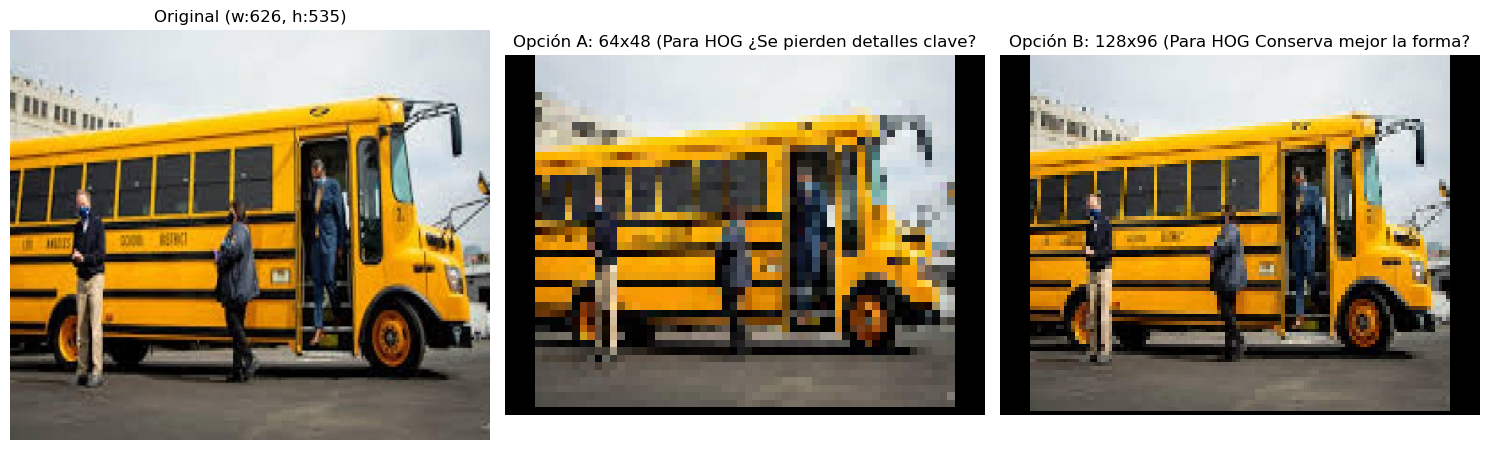

In [12]:
import cv2
import matplotlib.pyplot as plt
import os
import random

# 1. Seleccionar una imagen aleatoria de las positivas
positives_dir = 'dataset/positives'
sample_img_name = random.choice([f for f in os.listdir(positives_dir) if f.lower().endswith(('.jpg','.png'))])
img_path = os.path.join(positives_dir, sample_img_name)
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def resize_with_padding(image, target_w, target_h):
    h, w = image.shape[:2]
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(image, (new_w, new_h))
    
    top = (target_h - new_h) // 2
    bottom = target_h - new_h - top
    left = (target_w - new_w) // 2
    right = target_w - new_w - left
    
    padded = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0,0,0])
    return padded

# 2. Generar las dos opciones de ventana (múltiplos de 8)
# Opción A: 64x48 (Relación 1.33)
img_64x48 = resize_with_padding(img_rgb, 64, 48)

# Opción B: 128x96 (Relación 1.33)
img_128x96 = resize_with_padding(img_rgb, 128, 96)

# 3. Mostrar comparativa
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.imshow(img_rgb)
ax1.set_title(f'Original (w:{img.shape[1]}, h:{img.shape[0]})')
ax1.axis('off')

ax2.imshow(img_64x48)
ax2.set_title('Opción A: 64x48 (Para HOG ¿Se pierden detalles clave?')
ax2.axis('off')

ax3.imshow(img_128x96)
ax3.set_title('Opción B: 128x96 (Para HOG Conserva mejor la forma?')
ax3.axis('off')

plt.tight_layout()
plt.show()


# Fase 3: Extracción de Características HOG (Visión Computacional Clásica

**Experimento 3.1:** Parametrización del HOGDescriptor

- Aquí es donde vas a instanciar HOG en OpenCV: cv2.HOGDescriptor(winSize=(128,96), blockSize=(16,16), blockStride=(8,8), cellSize=(8,8), nbins=9).

- Mostrarás visualmente cómo se ve el HOG extraído de una de tus busetas a 128x96.

Descriptor HOG configurado. Tamaño del vector resultante: 5940 características por imagen.


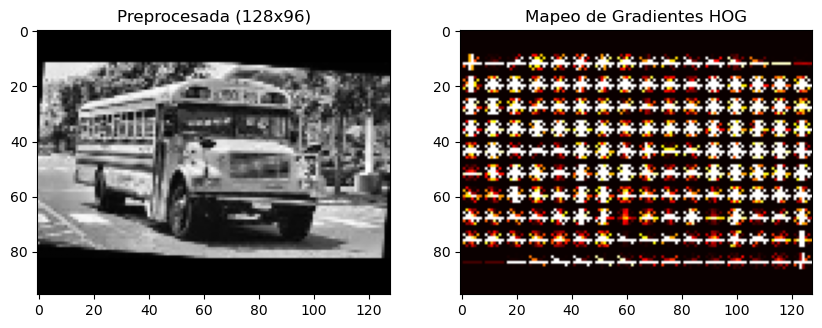

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
import random
import os

# 1. Parámetros HOG (Ventana 128x96)
winSize = (128, 96)
blockSize = (16, 16)
blockStride = (8, 8)
cellSize = (8, 8)
nbins = 9

# Instancia oficial de OpenCV para el entrenamiento futuro
hog_cv2 = cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, nbins)
print(f'Descriptor HOG configurado. Tamaño del vector resultante: {hog_cv2.getDescriptorSize()} características por imagen.')

# 2. Visualización con skimage (solo para ver cómo el HOG interpreta la buseta)
positives_dir = 'dataset/positives'
sample = random.choice([f for f in os.listdir(positives_dir) if f.endswith(('.jpg','.png'))])
img_path = os.path.join(positives_dir, sample)
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray_clahe = clahe.apply(gray)

# Padding a 128x96
h, w = gray_clahe.shape
scale = min(winSize[0] / w, winSize[1] / h)
new_w, new_h = int(w * scale), int(h * scale)
resized = cv2.resize(gray_clahe, (new_w, new_h))
top = (winSize[1] - new_h) // 2
bottom = winSize[1] - new_h - top
left = (winSize[0] - new_w) // 2
right = winSize[0] - new_w - left
img_final = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0])

# HOG skimage visualization
features, hog_image = hog(img_final, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(img_final, cmap='gray')
ax1.set_title(f'Preprocesada (128x96)')
ax2.imshow(hog_image_rescaled, cmap='hot')
ax2.set_title('Mapeo de Gradientes HOG')
plt.show()


In [14]:
import glob
import numpy as np
from skimage.feature import hog

def medir_caos(patron):
    archivos = glob.glob(patron)[:50] # Tomamos 50 de muestra
    caos_total = []
    for f in archivos:
        img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (128, 96))
        features = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
        caos_total.append(np.mean(features)) # Promedio de fuerza de los gradientes
    return np.mean(caos_total)

print("Fuerza de gradientes en originales:", medir_caos('dataset/positives/[0-9]*.jpg'))
print("Fuerza de gradientes en aumentadas (color):", medir_caos('dataset/positives/aug_color_*.jpg'))


Caos en Originales: 0.12410742798574662
Caos en Ruido Gaussiano: nan


/Users/andresmorocho/miniconda3/envs/vision/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/andresmorocho/miniconda3/envs/vision/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


**Experimento 3.2:** Extracción Masiva (El Dataset Final)

- Un ciclo for que recorra tus 4662 positivas y tus 4200 negativas, les aplique: Grises -> CLAHE -> Resize con Padding a 128x96 -> Extracción HOG.

- Guardar todo en una matriz X (características) y un vector y (etiquetas 1 y 0) listos para el SVM.

In [15]:
import random

def preprocess_and_extract(img_path, is_positive=True):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return []
    
    # 1. CLAHE (Igual para todos para mantener consistencia de iluminación)
    img_clahe = clahe.apply(img)
    h, w = img_clahe.shape
    
    features_list = []
    
    if is_positive:
        # Para los buses, mantenemos la lógica de resize + padding
        scale = min(winSize[0] / w, winSize[1] / h)
        new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))
        resized = cv2.resize(img_clahe, (new_w, new_h))
        top = (winSize[1] - new_h) // 2
        bottom = winSize[1] - new_h - top
        left = (winSize[0] - new_w) // 2
        right = winSize[0] - new_w - left
        img_final = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0])
        
        features = hog_cv2.compute(img_final)
        if features is not None:
            features_list.append(features.flatten())
            
    else:
        # PARA NEGATIVAS: Extraer parches (crops) aleatorios de 128x96 del fondo real
        # Asegurarnos de que la imagen sea más grande que la ventana
        if w >= winSize[0] and h >= winSize[1]:
            for _ in range(2):  # Sacamos 2 parches por foto negativa
                x = random.randint(0, w - winSize[0])
                y = random.randint(0, h - winSize[1])
                crop = img_clahe[y:y+winSize[1], x:x+winSize[0]]
                
                features = hog_cv2.compute(crop)
                if features is not None:
                    features_list.append(features.flatten())
        else:
            # Si por alguna razón la imagen negativa es chiquita, la tratamos como positiva
            scale = min(winSize[0] / w, winSize[1] / h)
            new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))
            resized = cv2.resize(img_clahe, (new_w, new_h))
            top = (winSize[1] - new_h) // 2
            bottom = winSize[1] - new_h - top
            left = (winSize[0] - new_w) // 2
            right = winSize[0] - new_w - left
            img_final = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0])
            
            features = hog_cv2.compute(img_final)
            if features is not None:
                features_list.append(features.flatten())

    return features_list

X, y = [], []

print("Extrayendo características de Positivas (Buses)...")
pos_files = [f for f in os.listdir(pos_dir) if f.endswith((".jpg",".png"))]
for f in tqdm(pos_files):
    feats = preprocess_and_extract(os.path.join(pos_dir, f), is_positive=True)
    for feat in feats:
        X.append(feat)
        y.append(1)  # 1 = Bus Escolar
        
print("Extrayendo características de Negativas (Fondo real recortado)...")
neg_files = [f for f in os.listdir(neg_dir) if f.endswith((".jpg",".png"))]
for f in tqdm(neg_files):
    feats = preprocess_and_extract(os.path.join(neg_dir, f), is_positive=False)
    for feat in feats:
        X.append(feat)
        y.append(0)  # 0 = No Bus Escolar

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(f"\n[OK] ¡Extracción completada!")
print(f"Total de muestras HOG: {len(X)} (Positivas: {sum(y==1)}, Negativas: {sum(y==0)})")

# Guardar en disco para no repetir esto a cada rato
np.save("X_features.npy", X)
np.save("y_labels.npy", y)
print("Archivos numpy (.npy) guardados con éxito.")


Extrayendo características de Positivas (Buses)...


100%|██████████| 3885/3885 [00:10<00:00, 384.90it/s]


Extrayendo características de Negativas (Fondo real recortado)...


100%|██████████| 4575/4575 [00:28<00:00, 162.82it/s]



✅ ¡Extracción completada!
Total de muestras HOG: 12869 (Positivas: 3885, Negativas: 8984)
Archivos numpy (.npy) guardados con éxito.


---
## Experimento 3.3: Análisis de Separabilidad Lineal (PCA)
**Objetivo:** El vector HOG tiene miles de dimensiones, lo que hace imposible visualizarlo. Aplicaremos *Principal Component Analysis (PCA)* para reducir esos miles de números a solo 2 dimensiones (X e Y) y graficarlos.


Aplicando PCA para reducir dimensionalidad de HOG a 2D...


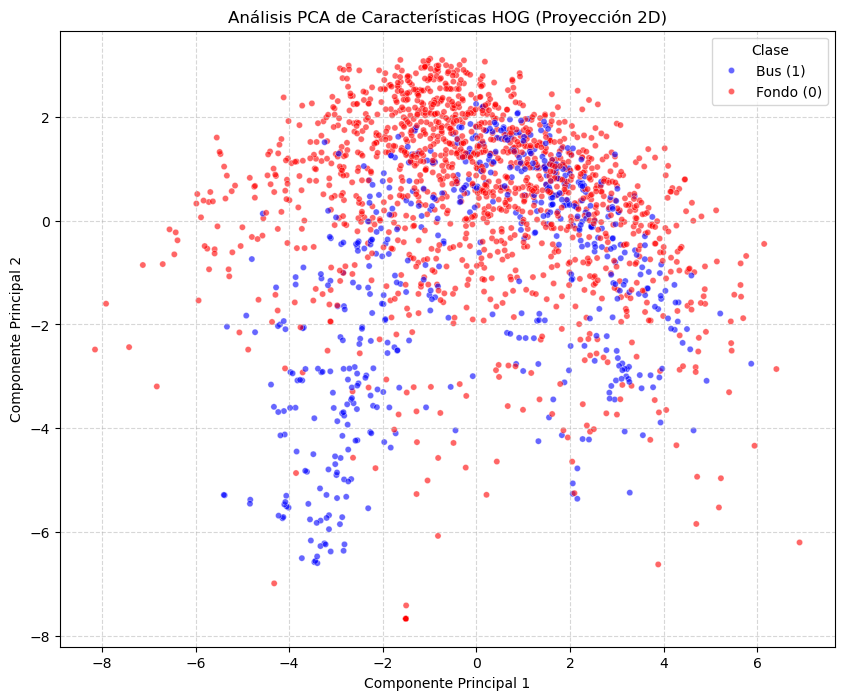

Varianza explicada por estas 2 componentes: 17.56%


In [16]:
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd

print("Aplicando PCA para reducir dimensionalidad de HOG a 2D...")
# Para no saturar la memoria, tomamos una muestra representativa (ej. 2000 muestras)
sample_size = min(2000, len(X))
indices = np.random.choice(len(X), sample_size, replace=False)
X_sample = X[indices]
y_sample = y[indices]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# Crear DataFrame para visualización
df_pca = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
df_pca['Clase'] = ['Bus (1)' if label == 1 else 'Fondo (0)' for label in y_sample]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Componente Principal 1', y='Componente Principal 2',
    hue='Clase',
    palette={'Bus (1)': 'blue', 'Fondo (0)': 'red'},
    data=df_pca,
    alpha=0.6,
    s=20
)
plt.title('Análisis PCA de Características HOG (Proyección 2D)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Varianza explicada por estas 2 componentes: {sum(pca.explained_variance_ratio_)*100:.2f}%")
